All imports OK
scikit-learn: 1.7.2
✅ CSV found: /Users/nadinehassan/Desktop/sign_language_translator_2/sign_language_translator/datasets 2/landmarks.csv

After merging duplicates:
  Shape   : (9814, 64)
  Classes : ['ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 'ha', 'haa', 'jeem', 'kaaf', 'khaa', 'la', 'laam', 'meem', 'nun', 'ra', 'saad', 'seen', 'sheen', 'ta', 'taa', 'thaa', 'thal', 'waw', 'ya', 'zay']
  Num     : 30

Rows per class:
label
ain      311
al       313
aleff    301
bb       306
dal      289
dha      310
dhad     303
fa       314
gaaf     297
ghain    313
ha       305
haa      291
jeem     305
kaaf     310
khaa     305
la       307
laam     305
meem     307
nun      298
ra       304
saad     315
seen     315
sheen    315
ta       311
taa      612
thaa     312
thal     315
waw      291
ya       629
zay      305

X shape     : (9814, 63)
Num classes : 30
Classes     : ['ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 'ha', 

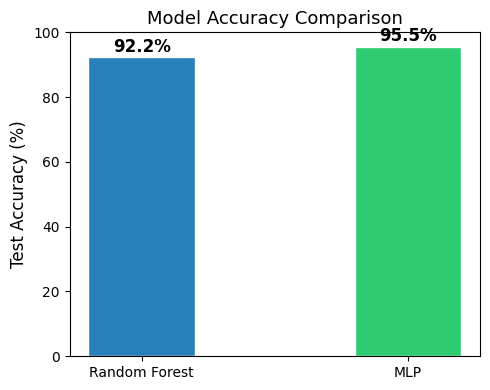

✅ Saved outputs/model_comparison.png


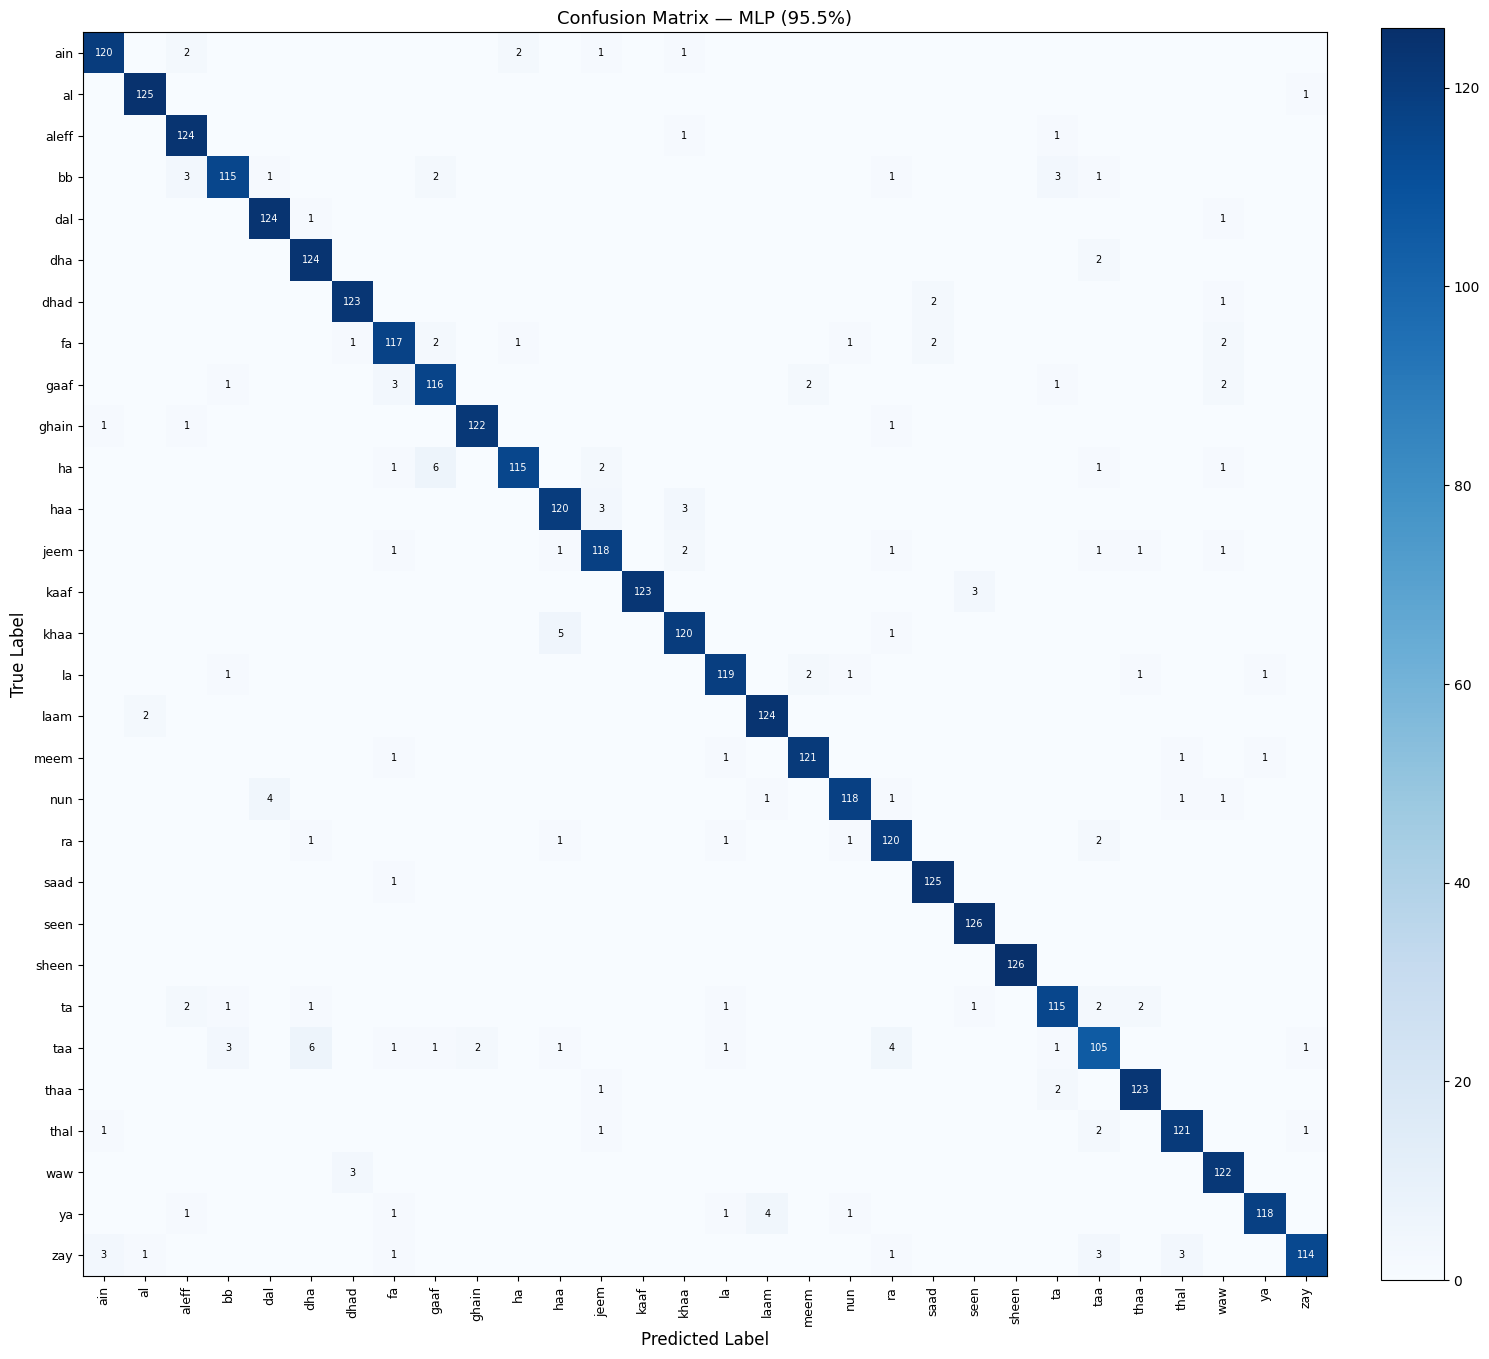

✅ Saved outputs/confusion_matrix.png


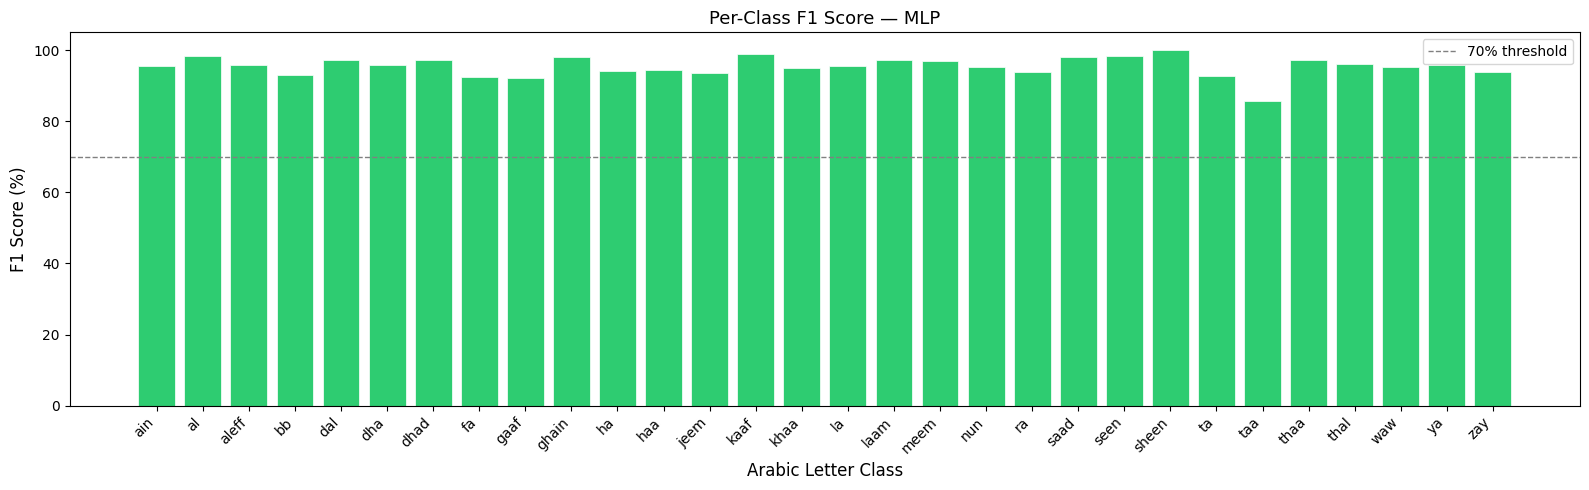

✅ Saved outputs/per_class_f1.png


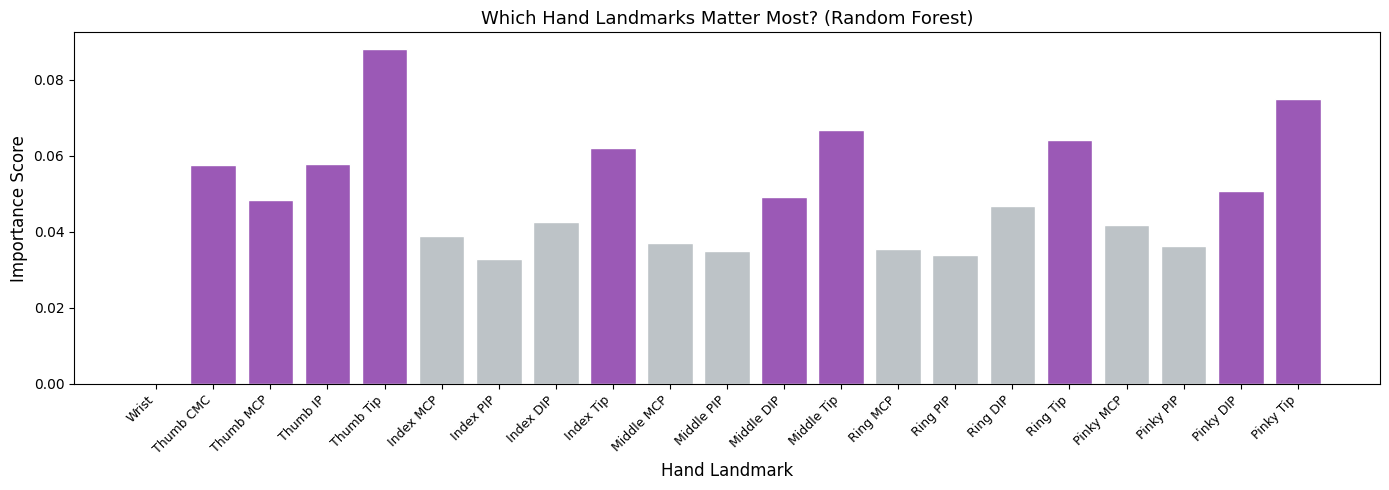

✅ Saved outputs/feature_importance.png


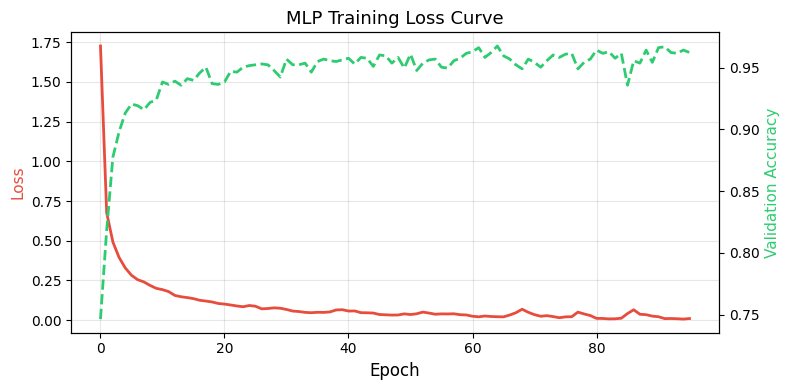

✅ Saved outputs/mlp_loss_curve.png
✅ arabic_letters.pkl saved
✅ rf_model.pkl saved  (308826 KB)
✅ mlp_model.pkl saved (2365 KB)
✅ label_encoder.pkl saved

Verification on 1 test sample:
  True label  : ya
  RF  predict : ya  (83.6%)  ✅
  MLP predict : ya  (100.0%)  ✅

         NOTEBOOK 03 COMPLETE
  RF  accuracy : 92.24%
  MLP accuracy : 95.47%
  Classes      : 30 (after merging duplicates)
  Models saved : /Users/nadinehassan/Desktop/sign_language_translator_2/sign_language_translator/models/

Next → app.py : Run the live demo


In [1]:
import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection     import train_test_split
from sklearn.preprocessing       import LabelEncoder, StandardScaler
from sklearn.ensemble            import RandomForestClassifier
from sklearn.neural_network      import MLPClassifier
from sklearn.metrics             import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling      import SMOTE

print("All imports OK")
print("scikit-learn:", __import__('sklearn').__version__)

# ── ONLY EDIT THESE ───────────────────────────────────────────────
CSV_PATH    = "../datasets 2/landmarks.csv"
MODELS_DIR  = "../models"
OUTPUTS_DIR = "../outputs"
# ──────────────────────────────────────────────────────────────────

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

assert os.path.isfile(CSV_PATH), f"❌ CSV not found: {CSV_PATH}"
print(f"✅ CSV found: {os.path.abspath(CSV_PATH)}")

# ════════════════════════════════════════════════════════════════
# STEP 1: LOAD + MERGE DUPLICATE CLASSES
# ya/yaa → ya  |  toot/taa → taa
# ════════════════════════════════════════════════════════════════
df = pd.read_csv(CSV_PATH)

MERGE_MAP = {
    'yaa'  : 'ya',
    'toot' : 'taa',
}
df['label'] = df['label'].replace(MERGE_MAP)

print(f"\nAfter merging duplicates:")
print(f"  Shape   : {df.shape}")
print(f"  Classes : {sorted(df['label'].unique())}")
print(f"  Num     : {df['label'].nunique()}")
print(f"\nRows per class:")
print(df['label'].value_counts().sort_index().to_string())

# ════════════════════════════════════════════════════════════════
# STEP 2: FEATURES + LABEL ENCODING
# ════════════════════════════════════════════════════════════════
X_raw = df.drop(columns=['label']).values.astype(np.float32)
y_raw = df['label'].values

le = LabelEncoder()
y  = le.fit_transform(y_raw)

print(f"\nX shape     : {X_raw.shape}")
print(f"Num classes : {len(le.classes_)}")
print(f"Classes     : {list(le.classes_)}")

# ════════════════════════════════════════════════════════════════
# STEP 3: SMOTE to balance dataset
# ════════════════════════════════════════════════════════════════
print("\nApplying SMOTE...")
smote = SMOTE(random_state=42, k_neighbors=3)
X_balanced, y_balanced = smote.fit_resample(X_raw, y)

unique, counts = np.unique(y_balanced, return_counts=True)
print(f"✅ After SMOTE: {len(X_balanced):,} samples")
print(f"   Each class has: {counts[0]} samples")

# ════════════════════════════════════════════════════════════════
# STEP 4: TRAIN/TEST SPLIT
# ════════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print(f"\nTraining samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")

# ════════════════════════════════════════════════════════════════
# STEP 5: SCALING — each model gets its own scaler
# ════════════════════════════════════════════════════════════════
rf_scaler   = StandardScaler()
X_train_rf  = rf_scaler.fit_transform(X_train)
X_test_rf   = rf_scaler.transform(X_test)

mlp_scaler  = StandardScaler()
X_train_mlp = mlp_scaler.fit_transform(X_train)
X_test_mlp  = mlp_scaler.transform(X_test)

print("✅ Scalers ready (RF + MLP separate)")

# ════════════════════════════════════════════════════════════════
# STEP 6: TRAIN RANDOM FOREST
# ════════════════════════════════════════════════════════════════
print("\nTraining Random Forest...")
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
)
rf_model.fit(X_train_rf, y_train)

rf_preds = rf_model.predict(X_test_rf)
rf_acc   = accuracy_score(y_test, rf_preds)
print(f"✅ RF done in {time.time()-t0:.1f}s  |  accuracy: {rf_acc*100:.2f}%")

# ════════════════════════════════════════════════════════════════
# STEP 7: TRAIN MLP
# ════════════════════════════════════════════════════════════════
print("\nTraining MLP...")
t0 = time.time()

mlp_model = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
    learning_rate_init=0.001,
)
mlp_model.fit(X_train_mlp, y_train)

mlp_preds = mlp_model.predict(X_test_mlp)
mlp_acc   = accuracy_score(y_test, mlp_preds)
print(f"✅ MLP done in {time.time()-t0:.1f}s  |  accuracy: {mlp_acc*100:.2f}%")

# ════════════════════════════════════════════════════════════════
# STEP 8: COMPARISON CHART
# ════════════════════════════════════════════════════════════════
print("\n" + "="*40)
print("       MODEL COMPARISON")
print("="*40)
print(f"  Random Forest : {rf_acc*100:.2f}%")
print(f"  MLP           : {mlp_acc*100:.2f}%")
print("="*40)

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#2980b9', '#2ecc71']
bars   = ax.bar(['Random Forest', 'MLP'],
                [rf_acc*100, mlp_acc*100],
                color=colors, width=0.4, edgecolor='white')
ax.set_ylim(0, 100)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=13)
for bar, val in zip(bars, [rf_acc, mlp_acc]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val*100:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/model_comparison.png", dpi=150)
plt.show()
print(f"✅ Saved outputs/model_comparison.png")

# ════════════════════════════════════════════════════════════════
# STEP 9: CONFUSION MATRIX (best model)
# ════════════════════════════════════════════════════════════════
best_model      = rf_model  if rf_acc >= mlp_acc else mlp_model
best_preds      = rf_preds  if rf_acc >= mlp_acc else mlp_preds
best_acc        = max(rf_acc, mlp_acc)
best_model_name = "Random Forest" if rf_acc >= mlp_acc else "MLP"

cm = confusion_matrix(y_test, best_preds)
n  = len(le.classes_)
figsize = max(12, n * 0.5)

fig, ax = plt.subplots(figsize=(figsize, figsize))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(le.classes_, rotation=90, fontsize=9)
ax.set_yticklabels(le.classes_, fontsize=9)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_model_name} ({best_acc*100:.1f}%)', fontsize=13)
for i in range(n):
    for j in range(n):
        val = cm[i, j]
        if val > 0:
            color = 'white' if cm[i,j] > cm.max()/2 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', fontsize=7, color=color)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Saved outputs/confusion_matrix.png")

# ════════════════════════════════════════════════════════════════
# STEP 10: PER-CLASS F1
# ════════════════════════════════════════════════════════════════
report   = classification_report(y_test, best_preds,
                                  target_names=le.classes_,
                                  output_dict=True, zero_division=0)
class_f1 = [report[cls]['f1-score'] for cls in le.classes_]
colors   = ['#2ecc71' if f >= 0.7 else '#e74c3c' for f in class_f1]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(le.classes_, [f*100 for f in class_f1], color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(70, color='gray', linestyle='--', linewidth=1, label='70% threshold')
ax.set_xlabel('Arabic Letter Class', fontsize=12)
ax.set_ylabel('F1 Score (%)', fontsize=12)
ax.set_title(f'Per-Class F1 Score — {best_model_name}', fontsize=13)
ax.set_ylim(0, 105)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/per_class_f1.png", dpi=150)
plt.show()
print(f"✅ Saved outputs/per_class_f1.png")

# ════════════════════════════════════════════════════════════════
# STEP 11: FEATURE IMPORTANCE (RF only)
# ════════════════════════════════════════════════════════════════
importances = rf_model.feature_importances_
landmark_importance = [
    importances[i*3] + importances[i*3+1] + importances[i*3+2]
    for i in range(21)
]
landmark_labels = [
    'Wrist',
    'Thumb CMC','Thumb MCP','Thumb IP','Thumb Tip',
    'Index MCP','Index PIP','Index DIP','Index Tip',
    'Middle MCP','Middle PIP','Middle DIP','Middle Tip',
    'Ring MCP','Ring PIP','Ring DIP','Ring Tip',
    'Pinky MCP','Pinky PIP','Pinky DIP','Pinky Tip'
]
colors = ['#9b59b6' if v >= np.mean(landmark_importance) else '#bdc3c7'
          for v in landmark_importance]
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(landmark_labels, landmark_importance, color=colors, edgecolor='white')
ax.set_xlabel('Hand Landmark', fontsize=12)
ax.set_ylabel('Importance Score', fontsize=12)
ax.set_title('Which Hand Landmarks Matter Most? (Random Forest)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/feature_importance.png", dpi=150)
plt.show()
print(f"✅ Saved outputs/feature_importance.png")

# ════════════════════════════════════════════════════════════════
# STEP 12: MLP LOSS CURVE
# ════════════════════════════════════════════════════════════════
if hasattr(mlp_model, 'loss_curve_'):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(mlp_model.loss_curve_, color='#e74c3c', linewidth=2, label='Training loss')
    if hasattr(mlp_model, 'validation_scores_') and mlp_model.validation_scores_:
        ax2 = ax.twinx()
        ax2.plot(mlp_model.validation_scores_, color='#2ecc71',
                 linewidth=2, linestyle='--', label='Validation accuracy')
        ax2.set_ylabel('Validation Accuracy', color='#2ecc71', fontsize=11)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', color='#e74c3c', fontsize=11)
    ax.set_title('MLP Training Loss Curve', fontsize=13)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUTS_DIR}/mlp_loss_curve.png", dpi=150)
    plt.show()
    print("✅ Saved outputs/mlp_loss_curve.png")

# ════════════════════════════════════════════════════════════════
# STEP 13: ARABIC LETTERS MAPPING
# ════════════════════════════════════════════════════════════════
ARABIC_LETTERS = {
    'ain'   : 'ع',
    'al'    : 'ال',
    'aleff' : 'ا',
    'bb'    : 'ب',
    'dal'   : 'د',
    'dha'   : 'ظ',
    'dhad'  : 'ض',
    'fa'    : 'ف',
    'gaaf'  : 'ق',
    'ghain' : 'غ',
    'ha'    : 'ه',
    'haa'   : 'ح',
    'jeem'  : 'ج',
    'kaaf'  : 'ك',
    'khaa'  : 'خ',
    'la'    : 'لا',
    'laam'  : 'ل',
    'meem'  : 'م',
    'nun'   : 'ن',
    'ra'    : 'ر',
    'saad'  : 'ص',
    'seen'  : 'س',
    'sheen' : 'ش',
    'ta'    : 'ط',
    'taa'   : 'ت',
    'thaa'  : 'ث',
    'thal'  : 'ذ',
    'waw'   : 'و',
    'ya'    : 'ي',
    'zay'   : 'ز',
}

with open(f"{MODELS_DIR}/arabic_letters.pkl", "wb") as f:
    pickle.dump(ARABIC_LETTERS, f)
print("✅ arabic_letters.pkl saved")

# ════════════════════════════════════════════════════════════════
# STEP 14: SAVE MODELS AS BUNDLES (model + scaler together)
# ════════════════════════════════════════════════════════════════
rf_bundle = {
    "model"  : rf_model,
    "scaler" : rf_scaler,
    "classes": list(le.classes_),
}
with open(f"{MODELS_DIR}/rf_model.pkl", "wb") as f:
    pickle.dump(rf_bundle, f)
print(f"✅ rf_model.pkl saved  ({os.path.getsize(f'{MODELS_DIR}/rf_model.pkl')//1024} KB)")

mlp_bundle = {
    "model"  : mlp_model,
    "scaler" : mlp_scaler,
    "classes": list(le.classes_),
}
with open(f"{MODELS_DIR}/mlp_model.pkl", "wb") as f:
    pickle.dump(mlp_bundle, f)
print(f"✅ mlp_model.pkl saved ({os.path.getsize(f'{MODELS_DIR}/mlp_model.pkl')//1024} KB)")

with open(f"{MODELS_DIR}/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print(f"✅ label_encoder.pkl saved")

# ════════════════════════════════════════════════════════════════
# STEP 15: VERIFY — load back and test one sample
# ════════════════════════════════════════════════════════════════
with open(f"{MODELS_DIR}/rf_model.pkl",      "rb") as f: rf_check  = pickle.load(f)
with open(f"{MODELS_DIR}/mlp_model.pkl",     "rb") as f: mlp_check = pickle.load(f)
with open(f"{MODELS_DIR}/label_encoder.pkl", "rb") as f: le_check  = pickle.load(f)

sample   = X_test[0:1]
true_lbl = le_check.classes_[y_test[0]]

s_rf  = rf_check["scaler"].transform(sample)
p_rf  = le_check.classes_[rf_check["model"].predict(s_rf)[0]]
c_rf  = rf_check["model"].predict_proba(s_rf).max() * 100

s_mlp = mlp_check["scaler"].transform(sample)
p_mlp = le_check.classes_[mlp_check["model"].predict(s_mlp)[0]]
c_mlp = mlp_check["model"].predict_proba(s_mlp).max() * 100

print(f"\nVerification on 1 test sample:")
print(f"  True label  : {true_lbl}")
print(f"  RF  predict : {p_rf}  ({c_rf:.1f}%)  {'✅' if p_rf==true_lbl else '❌'}")
print(f"  MLP predict : {p_mlp}  ({c_mlp:.1f}%)  {'✅' if p_mlp==true_lbl else '❌'}")

# ════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════════
print("\n" + "="*52)
print("         NOTEBOOK 03 COMPLETE")
print("="*52)
print(f"  RF  accuracy : {rf_acc*100:.2f}%")
print(f"  MLP accuracy : {mlp_acc*100:.2f}%")
print(f"  Classes      : {len(le.classes_)} (after merging duplicates)")
print(f"  Models saved : {os.path.abspath(MODELS_DIR)}/")
print("="*52)
print("\nNext → app.py : Run the live demo")

In [2]:
import os, shutil, yaml, cv2
import numpy as np

DATASET_PATH = "../datasets 2"
OUTPUT_PATH  = "../sign_language_translator_2/frontend/public/letter_images"
YAML_PATH    = "../datasets 2/sign.yaml"

os.makedirs(OUTPUT_PATH, exist_ok=True)

with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)
class_names = cfg['names']

IMAGES_DIR = os.path.join(DATASET_PATH, "train", "images")
LABELS_DIR = os.path.join(DATASET_PATH, "train", "labels")

IMG_EXTS = {'.jpg', '.jpeg', '.png'}

saved = []
for cls_id, cls_name in enumerate(class_names):
    label_files = sorted(os.listdir(LABELS_DIR))
    
    for lf in label_files:
        lbl_path = os.path.join(LABELS_DIR, lf)
        with open(lbl_path) as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            if int(parts[0]) != cls_id:
                continue
            
            # Found an image for this class
            stem = os.path.splitext(lf)[0]
            img_path = None
            for ext in IMG_EXTS:
                candidate = os.path.join(IMAGES_DIR, stem + ext)
                if os.path.exists(candidate):
                    img_path = candidate
                    break
            
            if img_path is None:
                continue
            
            # Crop the bounding box
            img = cv2.imread(img_path)
            img_h, img_w = img.shape[:2]
            cx, cy, w, h = map(float, parts[1:5])
            x1 = max(0, int((cx - w/2) * img_w))
            y1 = max(0, int((cy - h/2) * img_h))
            x2 = min(img_w, int((cx + w/2) * img_w))
            y2 = min(img_h, int((cy + h/2) * img_h))
            
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            
            # Resize to standard size
            crop_resized = cv2.resize(crop, (224, 224))
            
            # Save
            out_path = os.path.join(OUTPUT_PATH, f"{cls_name}.jpg")
            cv2.imwrite(out_path, crop_resized)
            saved.append(cls_name)
            break
        
        if cls_name in saved:
            break

print(f"✅ Saved {len(saved)} letter images to {OUTPUT_PATH}")
print(f"   Letters saved: {saved}")

✅ Saved 32 letter images to ../sign_language_translator_2/frontend/public/letter_images
   Letters saved: ['ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 'ha', 'haa', 'jeem', 'kaaf', 'khaa', 'la', 'laam', 'meem', 'nun', 'ra', 'saad', 'seen', 'sheen', 'ta', 'taa', 'thaa', 'thal', 'toot', 'waw', 'ya', 'yaa', 'zay']
